# Análise Inicial - Tênis Certificados pela World Athletics

**Disciplina:** Ciência de Dados  
**Instituição:** UEA - Engenharia de Computação  
**Data:** Novembro 2024

---

## Objetivo

Aplicar técnicas de compreensão e visualização de dados, explorando criticamente os atributos do dataset e identificando limitações e oportunidades para análise futura.

## Fonte dos Dados

World Athletics - Lista Completa de Tênis Certificados  
URL: https://certcheck.worldathletics.org/FullList

## 1. Importação de Bibliotecas e Carregamento dos Dados

In [1]:
# Importar bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Configurações de visualização
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Configurar pandas para exibir todas as colunas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

In [2]:
# Carregar os dados
df = pd.read_csv('dados_tenis_worldathletics.csv')

print("Dataset carregado com sucesso!")
print(f"\nDimensões: {df.shape[0]} linhas × {df.shape[1]} colunas")

Dataset carregado com sucesso!

Dimensões: 860 linhas × 11 colunas


## 2. Visão Geral dos Dados

In [3]:
# Exibir primeiras linhas
print("=== PRIMEIRAS 10 LINHAS DO DATASET ===")
df.head(10)

=== PRIMEIRAS 10 LINHAS DO DATASET ===


,Marca,Modelo,Aprovado_Pista,Aprovado_Saltos,Aprovado_Arremessos,Aprovado_Estrada_Marcha,Aprovado_Cross_Country,Tem_Data_Validade,Validade_Inicio,Validade_Fim,Nome_Original_Completo
0,361 Degrees,Biospeed Future,True,True,True,True,True,False,NaN,NaN,Biospeed Future
1,361 Degrees,Biospeed pro,False,False,False,True,True,False,NaN,NaN,Biospeed pro
2,361 Degrees,Flame,False,False,False,True,True,False,NaN,NaN,Flame
3,361 Degrees,Flame 2,False,False,False,True,True,False,NaN,NaN,Flame 2
4,361 Degrees,FLAME 5,False,False,False,True,True,True,24 SEP 2025,23 SEP 2026,FLAME 5\nVALID: 24 SEP 2025 - 23 SEP 2026
5,361 Degrees,FLAME 5 FUTURE,False,False,False,True,True,True,06 AUG 2025,05 AUG 2026,FLAME 5 FUTURE\nVALID: 06 AUG 2025 - 05 AUG 2026
6,361 Degrees,Furious,False,False,False,True,True,False,NaN,NaN,Furious
7,361 Degrees,Furious 2,False,False,False,True,True,False,NaN,NaN,Furious 2
8,361 Degrees,Furious Future,False,False,False,True,True,False,NaN,NaN,Furious Future
9,361 Degrees,Furious Future 2,False,False,False,True,True,False,NaN,NaN,Furious Future 2


In [4]:
# Informações gerais sobre o dataset
print("=== INFORMAÇÕES GERAIS ===")
df.info()

=== INFORMAÇÕES GERAIS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 860 entries, 0 to 859
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Marca                    860 non-null    object
 1   Modelo                   860 non-null    object
 2   Aprovado_Pista           860 non-null    bool  
 3   Aprovado_Saltos          860 non-null    bool  
 4   Aprovado_Arremessos      860 non-null    bool  
 5   Aprovado_Estrada_Marcha  860 non-null    bool  
 6   Aprovado_Cross_Country   860 non-null    bool  
 7   Tem_Data_Validade        860 non-null    bool  
 8   Validade_Inicio          69 non-null     object
 9   Validade_Fim             69 non-null     object
 10  Nome_Original_Completo   860 non-null    object
dtypes: bool(6), object(5)
memory usage: 38.8+ KB


In [5]:
# Estatísticas descritivas
print("=== ESTATÍSTICAS DESCRITIVAS ===")
df.describe(include='all').T

=== ESTATÍSTICAS DESCRITIVAS ===


,count,unique,top,freq
Marca,860,59,Mizuno,142
Modelo,860,859,Cielo Fly X Lite,2
Aprovado_Pista,860,2,True,449
Aprovado_Saltos,860,2,False,529
Aprovado_Arremessos,860,2,True,449
Aprovado_Estrada_Marcha,860,1,True,860
Aprovado_Cross_Country,860,2,True,859
Tem_Data_Validade,860,2,False,791
Validade_Inicio,69,53,06 AUG 2025,4
Validade_Fim,69,53,05 AUG 2026,4


## 3. Compreensão dos Atributos

### 3.1 Tabela de Classificação dos Atributos

Para cada atributo do dataset, vamos classificar:
- **Tipo**: nominal, ordinal, numérico discreto ou contínuo
- **Domínio**: valores possíveis ou intervalo esperado
- **Domínio Dinâmico**: se o domínio pode mudar ao longo do tempo
- **Escala**: para atributos numéricos (intervalo, proporção ou absoluta)

In [6]:
# Criar tabela de análise dos atributos
atributos_info = {
    'Atributo': [
        'Marca',
        'Modelo',
        'Aprovado_Pista',
        'Aprovado_Saltos',
        'Aprovado_Arremessos',
        'Aprovado_Estrada_Marcha',
        'Aprovado_Cross_Country',
        'Tem_Data_Validade',
        'Validade_Inicio',
        'Validade_Fim',
        'Nome_Original_Completo'
    ],
    'Tipo': [
        'Nominal',
        'Nominal',
        'Nominal (Binário)',
        'Nominal (Binário)',
        'Nominal (Binário)',
        'Nominal (Binário)',
        'Nominal (Binário)',
        'Nominal (Binário)',
        'Temporal (Data)',
        'Temporal (Data)',
        'Nominal (Texto)'
    ],
    'Domínio': [
        f'{df["Marca"].nunique()} marcas únicas',
        f'{df["Modelo"].nunique()} modelos únicos',
        'True, False',
        'True, False',
        'True, False',
        'True, False',
        'True, False',
        'True, False',
        'Datas entre 2024-2026 (quando presente)',
        'Datas entre 2025-2027 (quando presente)',
        'Texto livre com nome e observações'
    ],
    'Domínio_Dinâmico': [
        'Sim - novas marcas podem ser adicionadas',
        'Sim - novos modelos são lançados constantemente',
        'Não - valores fixos (True/False)',
        'Não - valores fixos (True/False)',
        'Não - valores fixos (True/False)',
        'Não - valores fixos (True/False)',
        'Não - valores fixos (True/False)',
        'Não - valores fixos (True/False)',
        'Sim - datas futuras serão adicionadas',
        'Sim - datas futuras serão adicionadas',
        'Sim - nomes e observações podem variar'
    ],
    'Escala': [
        'N/A (categórico)',
        'N/A (categórico)',
        'N/A (categórico)',
        'N/A (categórico)',
        'N/A (categórico)',
        'N/A (categórico)',
        'N/A (categórico)',
        'N/A (categórico)',
        'Intervalo (datas)',
        'Intervalo (datas)',
        'N/A (texto)'
    ],
    'Observações': [
        'Identifica o fabricante do tênis',
        'Nome específico do modelo de tênis',
        'Certificação para corridas em pista',
        'Certificação para modalidades de salto',
        'Certificação para modalidades de arremesso',
        'Certificação para corridas de rua e marcha atlética',
        'Certificação para corridas de cross country',
        'Indica se a certificação tem prazo de validade',
        'Data inicial da validade da certificação',
        'Data final da validade da certificação',
        'Nome completo incluindo informações de validade'
    ]
}

df_atributos = pd.DataFrame(atributos_info)

print("\n" + "="*100)
print("TABELA DE COMPREENSÃO DOS ATRIBUTOS")
print("="*100 + "\n")

# Exibir tabela formatada
df_atributos


TABELA DE COMPREENSÃO DOS ATRIBUTOS



,Atributo,Tipo,Domínio,Domínio_Dinâmico,Escala,Observações
0,Marca,Nominal,59 marcas únicas,Sim - novas marcas podem ser adicionadas,N/A (categórico),Identifica o fabricante do tênis
1,Modelo,Nominal,859 modelos únicos,Sim - novos modelos são lançados constantemente,N/A (categórico),Nome específico do modelo de tênis
2,Aprovado_Pista,Nominal (Binário),"True, False",Não - valores fixos (True/False),N/A (categórico),Certificação para corridas em pista
3,Aprovado_Saltos,Nominal (Binário),"True, False",Não - valores fixos (True/False),N/A (categórico),Certificação para modalidades de salto
4,Aprovado_Arremessos,Nominal (Binário),"True, False",Não - valores fixos (True/False),N/A (categórico),Certificação para modalidades de arremesso
5,Aprovado_Estrada_Marcha,Nominal (Binário),"True, False",Não - valores fixos (True/False),N/A (categórico),Certificação para corridas de rua e marcha atl...
6,Aprovado_Cross_Country,Nominal (Binário),"True, False",Não - valores fixos (True/False),N/A (categórico),Certificação para corridas de cross country
7,Tem_Data_Validade,Nominal (Binário),"True, False",Não - valores fixos (True/False),N/A (categórico),Indica se a certificação tem prazo de validade
8,Validade_Inicio,Temporal (Data),Datas entre 2024-2026 (quando presente),Sim - datas futuras serão adicionadas,Intervalo (datas),Data inicial da validade da certificação
9,Validade_Fim,Temporal (Data),Datas entre 2025-2027 (quando presente),Sim - datas futuras serão adicionadas,Intervalo (datas),Data final da validade da certificação


### 3.2 Análise Detalhada por Atributo

In [7]:
# Análise dos atributos categóricos
print("=== ANÁLISE DE VALORES ÚNICOS ===")
print(f"\nTotal de registros: {len(df)}\n")

for col in df.columns:
    n_unique = df[col].nunique()
    n_missing = df[col].isna().sum()
    pct_missing = (n_missing / len(df)) * 100
    
    print(f"{col}:")
    print(f"  - Valores únicos: {n_unique}")
    print(f"  - Valores ausentes: {n_missing} ({pct_missing:.1f}%)")
    print()

=== ANÁLISE DE VALORES ÚNICOS ===

Total de registros: 860

Marca:
  - Valores únicos: 59
  - Valores ausentes: 0 (0.0%)

Modelo:
  - Valores únicos: 859
  - Valores ausentes: 0 (0.0%)

Aprovado_Pista:
  - Valores únicos: 2
  - Valores ausentes: 0 (0.0%)

Aprovado_Saltos:
  - Valores únicos: 2
  - Valores ausentes: 0 (0.0%)

Aprovado_Arremessos:
  - Valores únicos: 2
  - Valores ausentes: 0 (0.0%)

Aprovado_Estrada_Marcha:
  - Valores únicos: 1
  - Valores ausentes: 0 (0.0%)

Aprovado_Cross_Country:
  - Valores únicos: 2
  - Valores ausentes: 0 (0.0%)

Tem_Data_Validade:
  - Valores únicos: 2
  - Valores ausentes: 0 (0.0%)

Validade_Inicio:
  - Valores únicos: 53
  - Valores ausentes: 791 (92.0%)

Validade_Fim:
  - Valores únicos: 53
  - Valores ausentes: 791 (92.0%)

Nome_Original_Completo:
  - Valores únicos: 860
  - Valores ausentes: 0 (0.0%)



### 3.3 Distribuição das Marcas

=== TOP 15 MARCAS COM MAIS MODELOS CERTIFICADOS ===
Marca
Mizuno          142
Asics           128
Nike             69
Puma             66
Adidas           60
New Balance      44
Saucony          37
HokaONeOne       30
Under Armour     26
Brooks           21
ON               21
Xtep             17
Li-Ning          17
ANTA             15
Descente         13
Name: count, dtype: int64


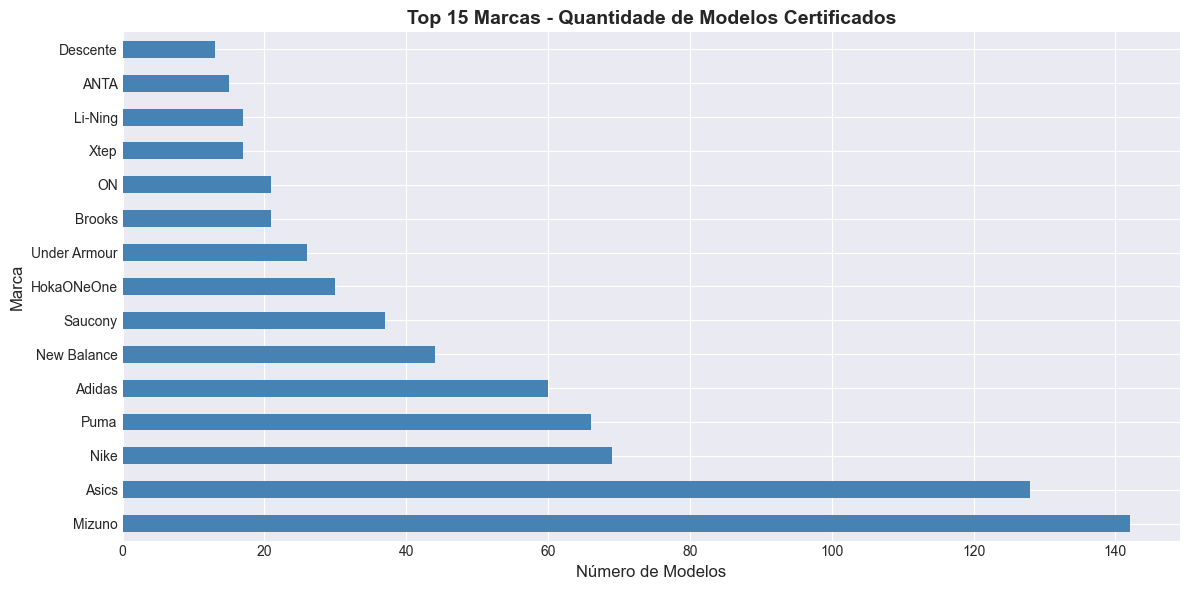

In [8]:
# Top 15 marcas
print("=== TOP 15 MARCAS COM MAIS MODELOS CERTIFICADOS ===")
top_brands = df['Marca'].value_counts().head(15)
print(top_brands)

# Visualização
plt.figure(figsize=(12, 6))
top_brands.plot(kind='barh', color='steelblue')
plt.title('Top 15 Marcas - Quantidade de Modelos Certificados', fontsize=14, fontweight='bold')
plt.xlabel('Número de Modelos', fontsize=12)
plt.ylabel('Marca', fontsize=12)
plt.tight_layout()
plt.show()

### 3.4 Distribuição das Aprovações por Modalidade

=== DISTRIBUIÇÃO DE APROVAÇÕES POR MODALIDADE ===
                Modalidade  Aprovados  Não Aprovados  Total  % Aprovados
             Pista (Track)        449            411    860        52.21
            Saltos (Jumps)        331            529    860        38.49
       Arremessos (Throws)        449            411    860        52.21
Estrada/Marcha (Road & RW)        860              0    860       100.00
             Cross Country        859              1    860        99.88


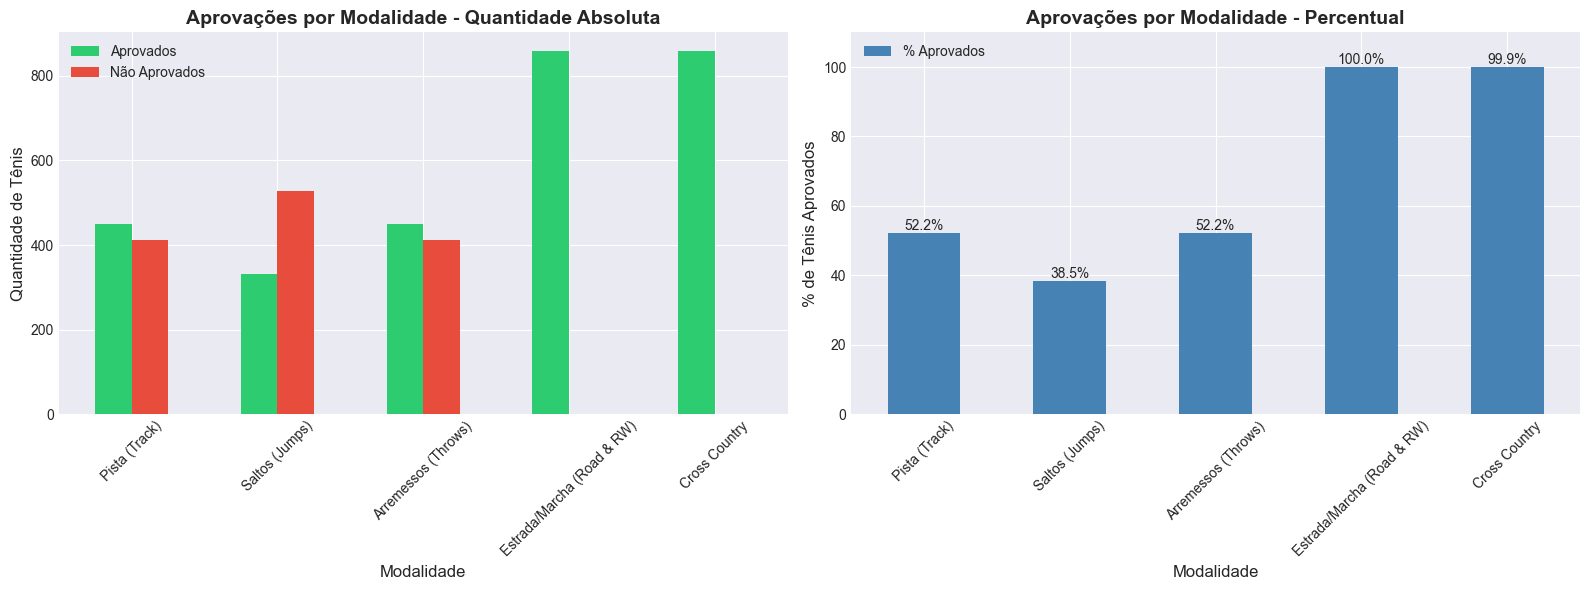

In [9]:
# Análise das aprovações
approval_cols = ['Aprovado_Pista', 'Aprovado_Saltos', 'Aprovado_Arremessos', 
                 'Aprovado_Estrada_Marcha', 'Aprovado_Cross_Country']

print("=== DISTRIBUIÇÃO DE APROVAÇÕES POR MODALIDADE ===")
approval_stats = pd.DataFrame({
    'Modalidade': ['Pista (Track)', 'Saltos (Jumps)', 'Arremessos (Throws)', 
                   'Estrada/Marcha (Road & RW)', 'Cross Country'],
    'Aprovados': [df[col].sum() for col in approval_cols],
    'Não Aprovados': [(~df[col]).sum() for col in approval_cols]
})

approval_stats['Total'] = approval_stats['Aprovados'] + approval_stats['Não Aprovados']
approval_stats['% Aprovados'] = (approval_stats['Aprovados'] / approval_stats['Total'] * 100).round(2)

print(approval_stats.to_string(index=False))

# Visualização
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de barras
approval_stats.plot(x='Modalidade', y=['Aprovados', 'Não Aprovados'], 
                   kind='bar', ax=ax1, color=['#2ecc71', '#e74c3c'])
ax1.set_title('Aprovações por Modalidade - Quantidade Absoluta', fontsize=14, fontweight='bold')
ax1.set_xlabel('Modalidade', fontsize=12)
ax1.set_ylabel('Quantidade de Tênis', fontsize=12)
ax1.legend(['Aprovados', 'Não Aprovados'])
ax1.tick_params(axis='x', rotation=45)

# Gráfico de percentual
approval_stats.plot(x='Modalidade', y='% Aprovados', kind='bar', ax=ax2, color='steelblue')
ax2.set_title('Aprovações por Modalidade - Percentual', fontsize=14, fontweight='bold')
ax2.set_xlabel('Modalidade', fontsize=12)
ax2.set_ylabel('% de Tênis Aprovados', fontsize=12)
ax2.tick_params(axis='x', rotation=45)
ax2.set_ylim(0, 110)

# Adicionar valores nas barras
for container in ax2.containers:
    ax2.bar_label(container, fmt='%.1f%%')

plt.tight_layout()
plt.show()

### 3.5 Análise de Certificações com Data de Validade

=== ANÁLISE DE DATAS DE VALIDADE ===

Tênis com data de validade: 69 (8.0%)
Tênis sem data de validade: 791 (92.0%)


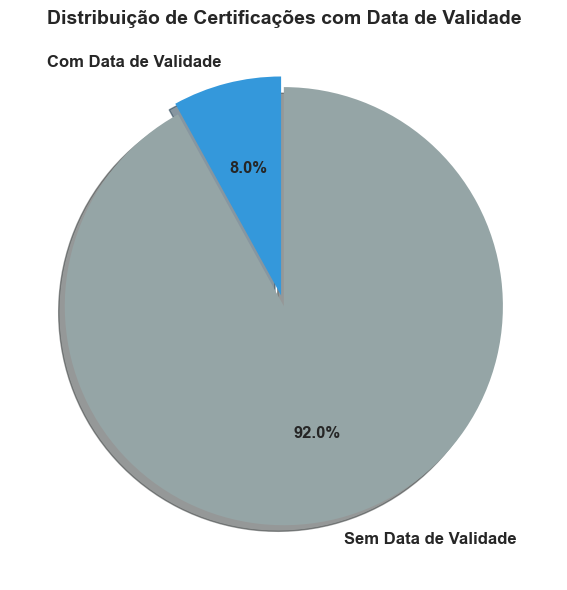


=== EXEMPLOS DE TÊNIS COM DATA DE VALIDADE ===
      Marca                     Modelo Validade_Inicio Validade_Fim
361 Degrees                    FLAME 5     24 SEP 2025  23 SEP 2026
361 Degrees             FLAME 5 FUTURE     06 AUG 2025  05 AUG 2026
910 Nineten           Geist Ekiden Pro     19 MAR 2025  18 MAR 2026
     Adidas ADIZERO ADIOS PRO EVO2 DEV     14 AUG 2025  13 AUG 2026
     Adidas      ADIZERO AVANTI LJ DEV     23 MAY 2025  22 MAY 2026
       ANTA                  C10 PRO 2     10 JAN 2025  09 JAN 2026
       ANTA              C10 PRO 2 CSP     04 JUN 2025  03 JUN 2026
       ANTA             C10 PRO 2 LCSP     16 JUN 2025  15 JUN 2026
       ANTA          TRACKEDGE SP -Dev     21 OCT 2025  20 OCT 2026
      Asics                 ME5 TYPE-1     27 OCT 2025  26 OCT 2026


In [10]:
# Análise de validade
has_validity = df['Tem_Data_Validade'].sum()
no_validity = (~df['Tem_Data_Validade']).sum()
pct_validity = (has_validity / len(df)) * 100

print("=== ANÁLISE DE DATAS DE VALIDADE ===")
print(f"\nTênis com data de validade: {has_validity} ({pct_validity:.1f}%)")
print(f"Tênis sem data de validade: {no_validity} ({100-pct_validity:.1f}%)")

# Visualização
fig, ax = plt.subplots(figsize=(10, 6))
labels = ['Com Data de Validade', 'Sem Data de Validade']
sizes = [has_validity, no_validity]
colors = ['#3498db', '#95a5a6']
explode = (0.05, 0)

ax.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
       shadow=True, startangle=90, textprops={'fontsize': 12, 'weight': 'bold'})
ax.set_title('Distribuição de Certificações com Data de Validade', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Mostrar exemplos de tênis com validade
print("\n=== EXEMPLOS DE TÊNIS COM DATA DE VALIDADE ===")
validity_examples = df[df['Tem_Data_Validade']][['Marca', 'Modelo', 'Validade_Inicio', 'Validade_Fim']].head(10)
print(validity_examples.to_string(index=False))

### 3.6 Análise de Múltiplas Certificações

=== DISTRIBUIÇÃO DO NÚMERO DE CERTIFICAÇÕES POR TÊNIS ===
Num_Certificacoes
1      1
2    410
4    118
5    331
Name: count, dtype: int64


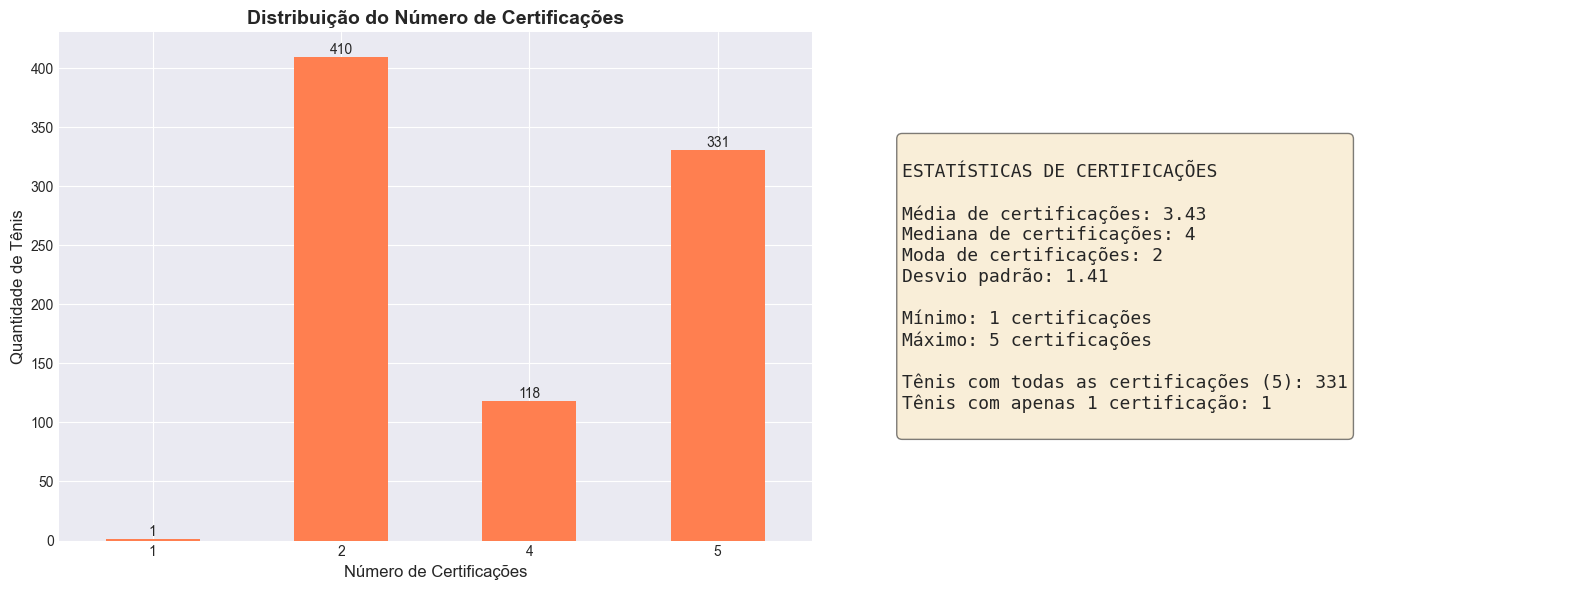


=== EXEMPLOS DE TÊNIS COM TODAS AS CERTIFICAÇÕES (5) ===
      Marca                Modelo
361 Degrees       Biospeed Future
     Adidas        Adizero Avanti
     Adidas     Adizero Avanti 24
     Adidas  Adizero Avanti Boost
     Adidas     Adizero Avanti LJ
     Adidas ADIZERO AVANTI LJ DEV
     Adidas    Adizero Avanti TYO
     Adidas     ADIZERO AVANTI XC
     Adidas Adizero Discus Hammer
     Adidas       Adizero Finesse


In [11]:
# Calcular número de certificações por tênis
df['Num_Certificacoes'] = df[approval_cols].sum(axis=1)

print("=== DISTRIBUIÇÃO DO NÚMERO DE CERTIFICAÇÕES POR TÊNIS ===")
cert_dist = df['Num_Certificacoes'].value_counts().sort_index()
print(cert_dist)

# Visualização
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de barras
cert_dist.plot(kind='bar', ax=ax1, color='coral')
ax1.set_title('Distribuição do Número de Certificações', fontsize=14, fontweight='bold')
ax1.set_xlabel('Número de Certificações', fontsize=12)
ax1.set_ylabel('Quantidade de Tênis', fontsize=12)
ax1.tick_params(axis='x', rotation=0)

# Adicionar valores nas barras
for container in ax1.containers:
    ax1.bar_label(container)

# Estatísticas descritivas
ax2.axis('off')
stats_text = f"""
ESTATÍSTICAS DE CERTIFICAÇÕES

Média de certificações: {df['Num_Certificacoes'].mean():.2f}
Mediana de certificações: {df['Num_Certificacoes'].median():.0f}
Moda de certificações: {df['Num_Certificacoes'].mode()[0]:.0f}
Desvio padrão: {df['Num_Certificacoes'].std():.2f}

Mínimo: {df['Num_Certificacoes'].min():.0f} certificações
Máximo: {df['Num_Certificacoes'].max():.0f} certificações

Tênis com todas as certificações (5): {(df['Num_Certificacoes'] == 5).sum()}
Tênis com apenas 1 certificação: {(df['Num_Certificacoes'] == 1).sum()}
"""
ax2.text(0.1, 0.5, stats_text, fontsize=13, family='monospace',
         verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# Mostrar tênis com todas as certificações
print("\n=== EXEMPLOS DE TÊNIS COM TODAS AS CERTIFICAÇÕES (5) ===")
all_certs = df[df['Num_Certificacoes'] == 5][['Marca', 'Modelo']].head(10)
print(all_certs.to_string(index=False))

### 3.7 Matriz de Correlação entre Certificações

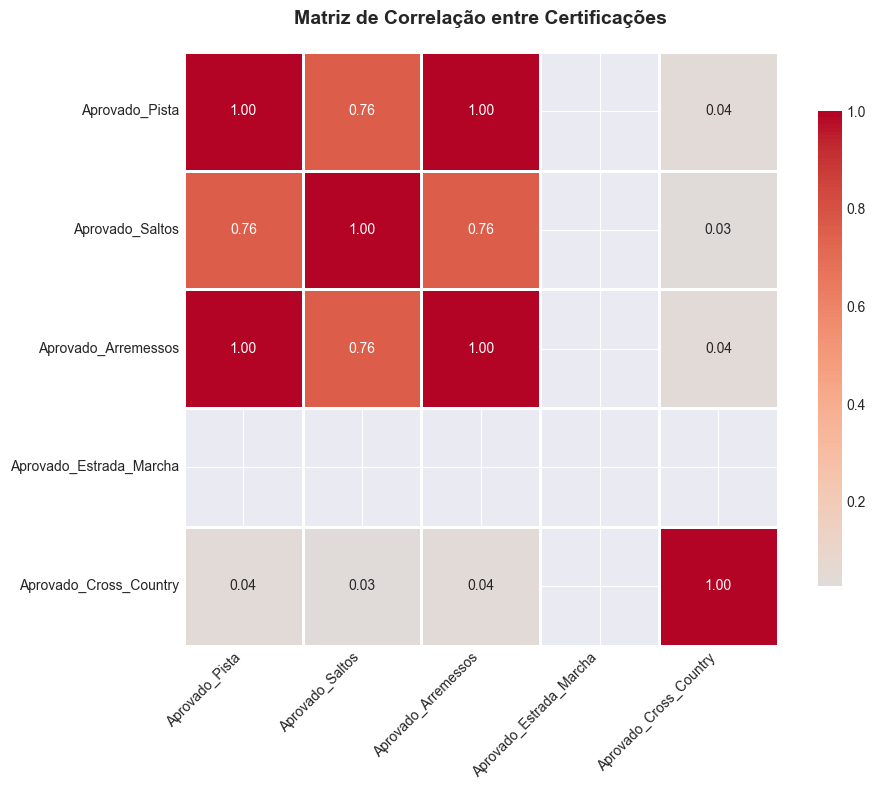


=== INTERPRETAÇÃO ===
Valores próximos de 1: certificações que tendem a aparecer juntas
Valores próximos de -1: certificações que raramente aparecem juntas
Valores próximos de 0: certificações independentes


In [12]:
# Criar matriz de correlação
corr_matrix = df[approval_cols].astype(int).corr()

# Visualização
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlação entre Certificações', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n=== INTERPRETAÇÃO ===")
print("Valores próximos de 1: certificações que tendem a aparecer juntas")
print("Valores próximos de -1: certificações que raramente aparecem juntas")
print("Valores próximos de 0: certificações independentes")

### 3.8 Análise de Certificações por Marca (Top 10)

=== PERCENTUAL DE APROVAÇÃO POR MODALIDADE - TOP 10 MARCAS ===
              Pista  Saltos  Arremessos  Estrada/Marcha  Cross Country
Marca                                                                 
Under Armour   76.9    65.4        76.9           100.0          100.0
Puma           71.2    48.5        71.2           100.0          100.0
Nike           71.0    66.7        71.0           100.0          100.0
Mizuno         68.3    54.2        68.3           100.0          100.0
Asics          62.5    45.3        62.5           100.0          100.0
Brooks         61.9    47.6        61.9           100.0          100.0
Adidas         53.3    38.3        53.3           100.0          100.0
New Balance    50.0    18.2        50.0           100.0          100.0
HokaONeOne     43.3    33.3        43.3           100.0          100.0
Saucony        43.2    43.2        43.2           100.0           97.3


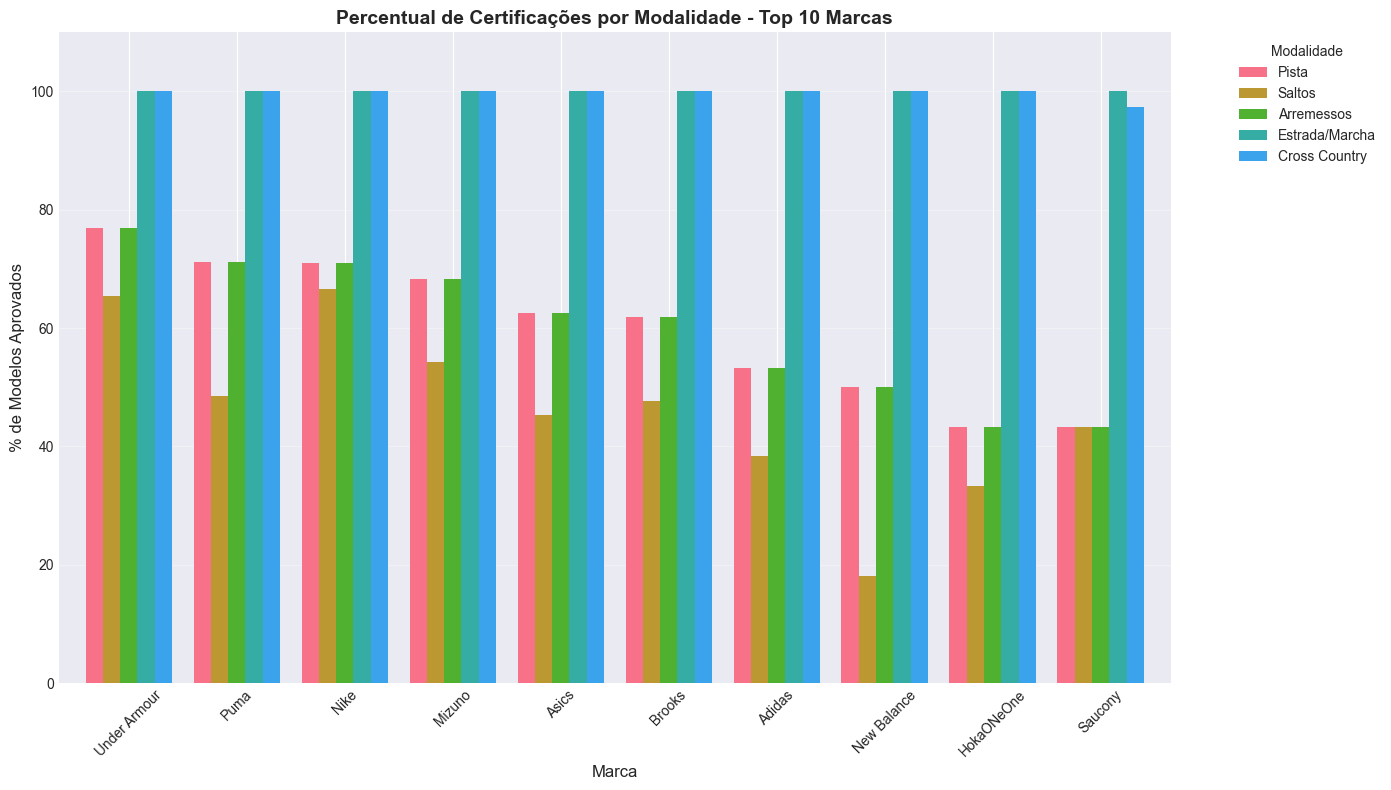

In [13]:
# Análise das top 10 marcas
top_10_brands = df['Marca'].value_counts().head(10).index
df_top10 = df[df['Marca'].isin(top_10_brands)]

# Calcular médias de aprovação por marca
brand_approvals = df_top10.groupby('Marca')[approval_cols].mean() * 100
brand_approvals.columns = ['Pista', 'Saltos', 'Arremessos', 'Estrada/Marcha', 'Cross Country']
brand_approvals = brand_approvals.sort_values('Pista', ascending=False)

print("=== PERCENTUAL DE APROVAÇÃO POR MODALIDADE - TOP 10 MARCAS ===")
print(brand_approvals.round(1))

# Visualização
fig, ax = plt.subplots(figsize=(14, 8))
brand_approvals.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Percentual de Certificações por Modalidade - Top 10 Marcas', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Marca', fontsize=12)
ax.set_ylabel('% de Modelos Aprovados', fontsize=12)
ax.legend(title='Modalidade', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.tick_params(axis='x', rotation=45)
ax.set_ylim(0, 110)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Identificação de Limitações do Dataset

### 4.1 Valores Ausentes

=== ANÁLISE DE VALORES AUSENTES ===
         Coluna  Valores_Ausentes  Percentual
Validade_Inicio               791       91.98
   Validade_Fim               791       91.98


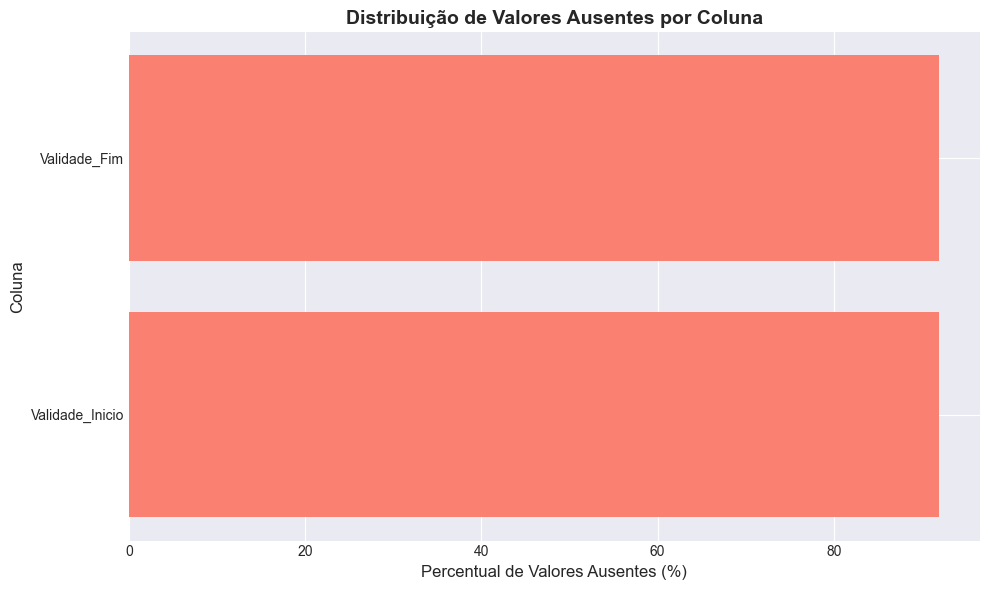

In [14]:
# Análise de valores ausentes
missing_data = pd.DataFrame({
    'Coluna': df.columns,
    'Valores_Ausentes': df.isnull().sum(),
    'Percentual': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_data = missing_data[missing_data['Valores_Ausentes'] > 0].sort_values('Valores_Ausentes', ascending=False)

print("=== ANÁLISE DE VALORES AUSENTES ===")
if len(missing_data) > 0:
    print(missing_data.to_string(index=False))
    
    # Visualização
    plt.figure(figsize=(10, 6))
    plt.barh(missing_data['Coluna'], missing_data['Percentual'], color='salmon')
    plt.xlabel('Percentual de Valores Ausentes (%)', fontsize=12)
    plt.ylabel('Coluna', fontsize=12)
    plt.title('Distribuição de Valores Ausentes por Coluna', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("✓ Não há valores ausentes no dataset!")

### 4.2 Limitações Identificadas

In [15]:
print("="*80)
print("LIMITAÇÕES IDENTIFICADAS NO DATASET")
print("="*80)

limitacoes = """
1. FALTA DE ATRIBUTOS TÉCNICOS:
   - Não há informações sobre especificações técnicas dos tênis
   - Faltam dados sobre: peso, altura do solado, drop, tecnologias utilizadas
   - Ausência de informações sobre materiais e construção

2. FALTA DE ATRIBUTOS DE PREÇO:
   - Não há informações sobre preços dos modelos
   - Impossibilita análises de relação custo-benefício
   - Dificulta comparações de posicionamento de mercado

3. DADOS TEMPORAIS LIMITADOS:
   - Apenas alguns tênis possuem datas de validade
   - Não há informação sobre data de lançamento dos modelos
   - Dificulta análise de tendências temporais

4. FALTA DE METADADOS:
   - Não há informações sobre quando o modelo foi certificado
   - Ausência de histórico de modificações/atualizações
   - Não há dados sobre o processo de certificação

5. INFORMAÇÕES DE USO:
   - Não há dados sobre público-alvo (iniciante, intermediário, elite)
   - Faltam informações sobre tipo de pisada recomendada
   - Ausência de recomendações de uso (distância, frequência)

6. DADOS DE PERFORMANCE:
   - Não há métricas de desempenho ou testes
   - Ausência de avaliações ou ratings
   - Faltam dados de durabilidade

7. PADRONIZAÇÃO:
   - Nomes de modelos podem estar duplicados com variações
   - Não há código único de identificação (SKU)
   - Possíveis inconsistências na nomenclatura
"""

print(limitacoes)

LIMITAÇÕES IDENTIFICADAS NO DATASET

1. FALTA DE ATRIBUTOS TÉCNICOS:
   - Não há informações sobre especificações técnicas dos tênis
   - Faltam dados sobre: peso, altura do solado, drop, tecnologias utilizadas
   - Ausência de informações sobre materiais e construção

2. FALTA DE ATRIBUTOS DE PREÇO:
   - Não há informações sobre preços dos modelos
   - Impossibilita análises de relação custo-benefício
   - Dificulta comparações de posicionamento de mercado

3. DADOS TEMPORAIS LIMITADOS:
   - Apenas alguns tênis possuem datas de validade
   - Não há informação sobre data de lançamento dos modelos
   - Dificulta análise de tendências temporais

4. FALTA DE METADADOS:
   - Não há informações sobre quando o modelo foi certificado
   - Ausência de histórico de modificações/atualizações
   - Não há dados sobre o processo de certificação

5. INFORMAÇÕES DE USO:
   - Não há dados sobre público-alvo (iniciante, intermediário, elite)
   - Faltam informações sobre tipo de pisada recomendada
   -

## 5. Oportunidades para Análises Futuras

In [16]:
print("="*80)
print("OPORTUNIDADES PARA ANÁLISES FUTURAS")
print("="*80)

oportunidades = """
1. ENRIQUECIMENTO DOS DADOS:
   ✓ Integrar dados de especificações técnicas de sites de fabricantes
   ✓ Adicionar informações de preços de marketplaces (Amazon, Netshoes)
   ✓ Incluir avaliações e reviews de usuários
   ✓ Coletar dados de vendas e popularidade

2. ANÁLISES DE MERCADO:
   ✓ Análise de posicionamento competitivo entre marcas
   ✓ Identificação de nichos de mercado (especialização por modalidade)
   ✓ Análise de estratégias de produto por fabricante
   ✓ Estudo de market share por modalidade

3. ANÁLISES TEMPORAIS:
   ✓ Evolução do número de certificações ao longo do tempo
   ✓ Análise de tendências de entrada de novas marcas
   ✓ Estudo de ciclo de vida dos modelos
   ✓ Previsão de renovações de certificação

4. ANÁLISES PREDITIVAS:
   ✓ Prever quais tênis terão múltiplas certificações
   ✓ Classificação automática de tênis por modalidade
   ✓ Recomendação de tênis baseada em perfil do atleta
   ✓ Previsão de preços baseada em características

5. ANÁLISES DE ESPECIALIZAÇÃO:
   ✓ Identificar marcas especialistas vs generalistas
   ✓ Analisar portfólio de produtos por fabricante
   ✓ Estudar padrões de certificação por tipo de tênis
   ✓ Avaliar estratégias de diversificação

6. VISUALIZAÇÕES INTERATIVAS:
   ✓ Criar dashboard interativo com filtros por marca/modalidade
   ✓ Desenvolver mapa de relacionamento marca-modalidade
   ✓ Implementar sistema de busca e comparação de tênis
   ✓ Criar visualizações em rede de certificações

7. ANÁLISES ESTATÍSTICAS AVANÇADAS:
   ✓ Clustering de marcas por perfil de certificações
   ✓ Análise de componentes principais (PCA)
   ✓ Teste de hipóteses sobre diferenças entre marcas
   ✓ Análise de associação entre modalidades

8. INTEGRAÇÃO COM OUTRAS FONTES:
   ✓ Cruzar com resultados de competições oficiais
   ✓ Analisar preferências de atletas profissionais
   ✓ Correlacionar com recordes e performances
   ✓ Estudar adoção de tecnologias específicas
"""

print(oportunidades)

OPORTUNIDADES PARA ANÁLISES FUTURAS

1. ENRIQUECIMENTO DOS DADOS:
   ✓ Integrar dados de especificações técnicas de sites de fabricantes
   ✓ Adicionar informações de preços de marketplaces (Amazon, Netshoes)
   ✓ Incluir avaliações e reviews de usuários
   ✓ Coletar dados de vendas e popularidade

2. ANÁLISES DE MERCADO:
   ✓ Análise de posicionamento competitivo entre marcas
   ✓ Identificação de nichos de mercado (especialização por modalidade)
   ✓ Análise de estratégias de produto por fabricante
   ✓ Estudo de market share por modalidade

3. ANÁLISES TEMPORAIS:
   ✓ Evolução do número de certificações ao longo do tempo
   ✓ Análise de tendências de entrada de novas marcas
   ✓ Estudo de ciclo de vida dos modelos
   ✓ Previsão de renovações de certificação

4. ANÁLISES PREDITIVAS:
   ✓ Prever quais tênis terão múltiplas certificações
   ✓ Classificação automática de tênis por modalidade
   ✓ Recomendação de tênis baseada em perfil do atleta
   ✓ Previsão de preços baseada em caract

## 6. Conclusões

### 6.1 Principais Descobertas

In [17]:
print("="*80)
print("PRINCIPAIS DESCOBERTAS")
print("="*80)

# Calcular estatísticas finais
total_shoes = len(df)
total_brands = df['Marca'].nunique()
top_brand = df['Marca'].value_counts().index[0]
top_brand_count = df['Marca'].value_counts().iloc[0]
avg_certs = df['Num_Certificacoes'].mean()
most_common_certs = df['Num_Certificacoes'].mode()[0]
road_approval = (df['Aprovado_Estrada_Marcha'].sum() / total_shoes * 100)
track_approval = (df['Aprovado_Pista'].sum() / total_shoes * 100)

conclusoes = f"""
1. DIMENSÃO DO DATASET:
   • Total de {total_shoes} modelos de tênis certificados
   • Representando {total_brands} marcas diferentes
   • {top_brand} lidera com {top_brand_count} modelos certificados

2. PADRÕES DE CERTIFICAÇÃO:
   • {road_approval:.1f}% dos tênis são aprovados para Estrada/Marcha
   • {track_approval:.1f}% dos tênis são aprovados para Pista
   • Média de {avg_certs:.2f} certificações por tênis
   • Moda de {most_common_certs:.0f} certificações (mais comum)

3. ESPECIALIZAÇÃO DE MERCADO:
   • Marcas tradicionais (Mizuno, Asics, Nike) dominam o mercado
   • Forte correlação entre certificações de Estrada/Marcha e Cross Country
   • Menor correlação entre Saltos e outras modalidades (maior especialização)

4. VALIDAÇÃO TEMPORAL:
   • Apenas alguns modelos têm datas de validade específicas
   • Indicação de certificações temporárias vs permanentes
   • Oportunidade para monitoramento de renovações

5. QUALIDADE DOS DADOS:
   • Dataset limpo sem valores ausentes críticos
   • Estrutura bem definida e consistente
   • Pronto para análises mais aprofundadas

6. APLICAÇÕES PRÁTICAS:
   • Útil para atletas na escolha de equipamento adequado
   • Valioso para fabricantes analisarem concorrência
   • Importante para organizadores de eventos verificarem conformidade
"""

print(conclusoes)

PRINCIPAIS DESCOBERTAS

1. DIMENSÃO DO DATASET:
   • Total de 860 modelos de tênis certificados
   • Representando 59 marcas diferentes
   • Mizuno lidera com 142 modelos certificados

2. PADRÕES DE CERTIFICAÇÃO:
   • 100.0% dos tênis são aprovados para Estrada/Marcha
   • 52.2% dos tênis são aprovados para Pista
   • Média de 3.43 certificações por tênis
   • Moda de 2 certificações (mais comum)

3. ESPECIALIZAÇÃO DE MERCADO:
   • Marcas tradicionais (Mizuno, Asics, Nike) dominam o mercado
   • Forte correlação entre certificações de Estrada/Marcha e Cross Country
   • Menor correlação entre Saltos e outras modalidades (maior especialização)

4. VALIDAÇÃO TEMPORAL:
   • Apenas alguns modelos têm datas de validade específicas
   • Indicação de certificações temporárias vs permanentes
   • Oportunidade para monitoramento de renovações

5. QUALIDADE DOS DADOS:
   • Dataset limpo sem valores ausentes críticos
   • Estrutura bem definida e consistente
   • Pronto para análises mais aprofun

### 6.2 Resumo da Tabela de Atributos

In [18]:
# Exibir novamente a tabela de atributos para referência final
print("\n" + "="*100)
print("RESUMO FINAL - CLASSIFICAÇÃO DOS ATRIBUTOS")
print("="*100 + "\n")

display(df_atributos)


RESUMO FINAL - CLASSIFICAÇÃO DOS ATRIBUTOS



,Atributo,Tipo,Domínio,Domínio_Dinâmico,Escala,Observações
0,Marca,Nominal,59 marcas únicas,Sim - novas marcas podem ser adicionadas,N/A (categórico),Identifica o fabricante do tênis
1,Modelo,Nominal,859 modelos únicos,Sim - novos modelos são lançados constantemente,N/A (categórico),Nome específico do modelo de tênis
2,Aprovado_Pista,Nominal (Binário),"True, False",Não - valores fixos (True/False),N/A (categórico),Certificação para corridas em pista
3,Aprovado_Saltos,Nominal (Binário),"True, False",Não - valores fixos (True/False),N/A (categórico),Certificação para modalidades de salto
4,Aprovado_Arremessos,Nominal (Binário),"True, False",Não - valores fixos (True/False),N/A (categórico),Certificação para modalidades de arremesso
5,Aprovado_Estrada_Marcha,Nominal (Binário),"True, False",Não - valores fixos (True/False),N/A (categórico),Certificação para corridas de rua e marcha atl...
6,Aprovado_Cross_Country,Nominal (Binário),"True, False",Não - valores fixos (True/False),N/A (categórico),Certificação para corridas de cross country
7,Tem_Data_Validade,Nominal (Binário),"True, False",Não - valores fixos (True/False),N/A (categórico),Indica se a certificação tem prazo de validade
8,Validade_Inicio,Temporal (Data),Datas entre 2024-2026 (quando presente),Sim - datas futuras serão adicionadas,Intervalo (datas),Data inicial da validade da certificação
9,Validade_Fim,Temporal (Data),Datas entre 2025-2027 (quando presente),Sim - datas futuras serão adicionadas,Intervalo (datas),Data final da validade da certificação


---

## Referências

- World Athletics. (2024). *List of Approved Athletic Shoes*. Disponível em: https://certcheck.worldathletics.org/FullList
- Dados coletados em: Novembro 2024

---

**Disciplina:** Ciência de Dados  
**Instituição:** UEA - Engenharia de Computação  
**Objetivo:** Compreensão e Visualização de Dados

---